In [1]:
# (placeholder removed — see markdown cell below)
pass


# Feature selection autopsy (V6 / feature-selection-2.0)

This notebook freezes the diagnosis from past experiments: hand-selected MDR-v25 features on `derived_8.0`, automated pipeline outputs (opt-1.0), and `derived_8.2` V0–V5 / regime sets. It quantifies family composition, overlaps, and hard failure modes (no satellite, spatial collapse) that the new pipeline must avoid.


In [2]:
from pathlib import Path
import json
import importlib.util
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
# walk up until we find AGENTS.md / data/splits
for p in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (p / "data" / "splits").is_dir() and (p / "Modeling").is_dir():
        PROJECT_ROOT = p
        break
sys.path.insert(0, str(PROJECT_ROOT))

EXP_DIR = PROJECT_ROOT / "notebooks" / "experiment" / "derived_8.2-feature-selection-2.0"
OUT_DIR = EXP_DIR / "artifacts" / "analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

from Modeling.Src.soilmoist_fl.Selectors.family_coverage import (
    infer_coverage_family,
    group_by_coverage_family,
)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUT_DIR:", OUT_DIR)


PROJECT_ROOT: /scratch/user/u.rp352032/MDR-Project
OUT_DIR: /scratch/user/u.rp352032/MDR-Project/notebooks/experiment/derived_8.2-feature-selection-2.0/artifacts/analysis


## Load reference feature sets

We load: hand MDR-v25 features, the automated `derived_8.0` opt-1.0 set, and all `OVERALL_SELECTED_FEATURES_V*` plus regime sets from `dataset_metadata.py`.


In [3]:
HAND_MDR_V25 = [
    "SMAP_sm_pm_interp_ema02", "V_rollmin_LST_modis_kobs30", "D_sin_DOY", "G_rain_sum_3d",
    "V_ema_G_API_kobs7", "V_rollmin_G_API_kobs30", "G_rain_sum_7d", "C_lag_LST_modis_kobs30",
    "C_lag_G_API_kobs1", "V_ema_G_API_kobs14", "V_rollmean_G_API_kobs14", "G_API", "G_DSLR",
    "SMAP_ampm_diff_interp", "V_rollmax_G_API_kobs30", "V_ema_G_API_kobs30", "V_rollmean_s2_b11_kobs7",
    "V_ema_LST_modis_kobs7", "V_rollmean_G_API_kobs7", "C_lag_s2_b11_kobs30", "A_d_E_SAR_diff_kobs14",
    "C_lag_LST_modis_kobs6", "A_d_LST_modis_kobs14", "A_d_SMAP_sm_interp_kobs14",
    "V_rollstd_SMAP_sm_interp_kobs30", "SMAP_sm_interp_grad7", "year_frac", "sin_year", "cos_year",
    "API_x_year", "SMAP_x_year", "slope", "elev", "K_slope_sin", "K_slope_cos", "K_aspect_cos",
    "J_clay_wfrac_b0", "J_sand_wfrac_b0",
]

opt10_path = PROJECT_ROOT / "notebooks/experiment/derived_8.0-optimization-1.0/selected_features.json"
OPT10_8_0 = json.loads(opt10_path.read_text())

spec = importlib.util.spec_from_file_location(
    "dm82", PROJECT_ROOT / "data/splits/derived_8.2/dataset_metadata.py"
)
dm = importlib.util.module_from_spec(spec)
spec.loader.exec_module(dm)

feature_sets = {
    "hand_mdr_v25": HAND_MDR_V25,
    "opt1.0_pipeline_8.0": OPT10_8_0,
    "V0": list(dm.OVERALL_SELECTED_FEATURES_V0),
    "V1": list(dm.OVERALL_SELECTED_FEATURES_V1),
    "V2": list(dm.OVERALL_SELECTED_FEATURES_V2),
    "V3": list(dm.OVERALL_SELECTED_FEATURES_V3),
    "V4": list(dm.OVERALL_SELECTED_FEATURES_V4),
    "V5": list(dm.OVERALL_SELECTED_FEATURES_V5),
    "regime_ternary_wet_v1": list(dm.TERNARY_REGIME_WET_SELECTED_FEATURES_V1),
    "regime_ternary_transition_v1": list(dm.TERNARY_REGIME_TRANSITION_SELECTED_FEATURES_V1),
}

for name, feats in feature_sets.items():
    print(f"{name:32s} n={len(feats):3d}")


hand_mdr_v25                     n= 38
opt1.0_pipeline_8.0              n= 50
V0                               n= 40
V1                               n= 40
V2                               n= 40
V3                               n= 47
V4                               n= 50
V5                               n= 32
regime_ternary_wet_v1            n=  6
regime_ternary_transition_v1     n= 50


## Family composition and overlap with the hand set

Coverage families are structural (satellite / hydro / static / calendar / temporal), not a hard-coded whitelist of useful columns. We also report which hand-selected features the automated 8.0 pipeline missed.


In [4]:
rows = []
for name, feats in feature_sets.items():
    counts = {k: len(v) for k, v in group_by_coverage_family(feats).items()}
    row = {"set": name, "n": len(feats)}
    for fam in ["satellite", "hydro", "static", "calendar", "temporal", "other"]:
        row[fam] = counts.get(fam, 0)
    rows.append(row)

family_df = pd.DataFrame(rows).set_index("set")
family_df.to_csv(OUT_DIR / "family_counts.csv")
display(family_df)

# Overlap with hand set
hand = set(HAND_MDR_V25)
overlap_rows = []
for name, feats in feature_sets.items():
    s = set(feats)
    overlap_rows.append({
        "set": name,
        "n": len(s),
        "overlap_hand": len(s & hand),
        "jaccard_hand": len(s & hand) / len(s | hand) if (s | hand) else 0.0,
        "hand_only_count": len(hand - s),
    })
overlap_df = pd.DataFrame(overlap_rows).set_index("set")
overlap_df.to_csv(OUT_DIR / "overlap_with_hand.csv")
display(overlap_df)

missed_by_opt10 = sorted(hand - set(OPT10_8_0))
print(f"\nHand features missed by opt-1.0 pipeline ({len(missed_by_opt10)}):")
for f in missed_by_opt10:
    print(f"  - {f:40s} family={infer_coverage_family(f)}")

(OUT_DIR / "hand_missed_by_opt10.json").write_text(json.dumps({
    "missed": missed_by_opt10,
    "by_family": {
        fam: [f for f in missed_by_opt10 if infer_coverage_family(f) == fam]
        for fam in ["satellite", "hydro", "static", "calendar", "temporal", "other"]
    },
}, indent=2))


,n,satellite,hydro,static,calendar,temporal,other
set,,,,,,,
hand_mdr_v25,38,13,12,7,6,0,0
opt1.0_pipeline_8.0,50,31,6,3,10,0,0
V0,40,34,4,0,2,0,0
V1,40,21,1,8,10,0,0
V2,40,18,4,13,5,0,0
V3,47,24,4,11,8,0,0
V4,50,38,12,0,0,0,0
V5,32,25,7,0,0,0,0
regime_ternary_wet_v1,6,1,0,3,2,0,0


,n,overlap_hand,jaccard_hand,hand_only_count
set,,,,
hand_mdr_v25,38,38,1.000000,0
opt1.0_pipeline_8.0,50,9,0.113924,29
V0,40,5,0.068493,33
V1,40,5,0.068493,33
V2,40,10,0.147059,28
V3,47,11,0.148649,27
V4,50,6,0.073171,32
V5,32,4,0.060606,34
regime_ternary_wet_v1,6,2,0.047619,36



Hand features missed by opt-1.0 pipeline (29):
  - API_x_year                               family=calendar
  - A_d_E_SAR_diff_kobs14                    family=satellite
  - A_d_LST_modis_kobs14                     family=satellite
  - A_d_SMAP_sm_interp_kobs14                family=satellite
  - C_lag_G_API_kobs1                        family=hydro
  - C_lag_LST_modis_kobs6                    family=satellite
  - C_lag_s2_b11_kobs30                      family=satellite
  - J_clay_wfrac_b0                          family=static
  - J_sand_wfrac_b0                          family=static
  - K_aspect_cos                             family=static
  - K_slope_cos                              family=static
  - K_slope_sin                              family=static
  - SMAP_sm_interp_grad7                     family=satellite
  - SMAP_sm_pm_interp_ema02                  family=satellite
  - V_ema_G_API_kobs14                       family=hydro
  - V_ema_G_API_kobs30                       f

1710

## Coverage failure checks

These assertions encode known bad scenarios. A selection that fails them should not be promoted.


,status,flags,satellite,hydro,static,calendar,n
set,,,,,,,
hand_mdr_v25,OK,,13,12,7,6,38
opt1.0_pipeline_8.0,OK,,31,6,3,10,50
V0,FAIL,NO_STATIC,34,4,0,2,40
V1,OK,,21,1,8,10,40
V2,OK,,18,4,13,5,40
V3,OK,,24,4,11,8,47
V4,FAIL,NO_STATIC|NO_CALENDAR,38,12,0,0,50
V5,FAIL,NO_STATIC|NO_CALENDAR,25,7,0,0,32
regime_ternary_wet_v1,FAIL,NO_HYDRO,1,0,3,2,6



Known failures (expected):
  V4: FAIL NO_STATIC|NO_CALENDAR
  V5: FAIL NO_STATIC|NO_CALENDAR
  regime_ternary_wet_v1: FAIL NO_HYDRO
  opt1.0_pipeline_8.0: OK 


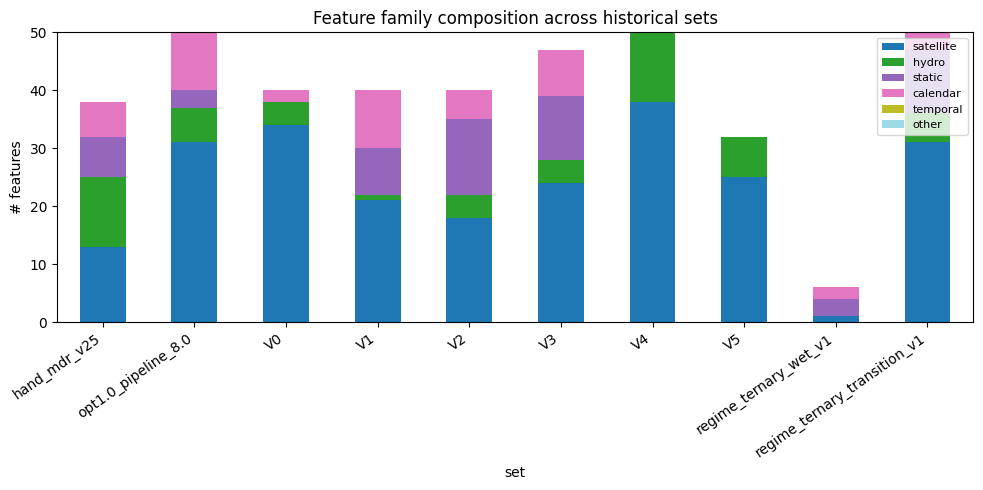

Saved: /scratch/user/u.rp352032/MDR-Project/notebooks/experiment/derived_8.2-feature-selection-2.0/artifacts/analysis/family_histograms.png


In [5]:
def coverage_report(feats, label):
    groups = group_by_coverage_family(feats)
    sat = len(groups.get("satellite", []))
    hydro = len(groups.get("hydro", []))
    static = len(groups.get("static", []))
    cal = len(groups.get("calendar", []))
    flags = []
    if sat == 0:
        flags.append("NO_SATELLITE")
    if hydro == 0:
        flags.append("NO_HYDRO")
    if static == 0:
        flags.append("NO_STATIC")
    if cal == 0:
        flags.append("NO_CALENDAR")
    status = "FAIL" if flags else "OK"
    return {
        "set": label,
        "status": status,
        "flags": "|".join(flags) if flags else "",
        "satellite": sat,
        "hydro": hydro,
        "static": static,
        "calendar": cal,
        "n": len(feats),
    }

check_rows = [coverage_report(feats, name) for name, feats in feature_sets.items()]
check_df = pd.DataFrame(check_rows).set_index("set")
check_df.to_csv(OUT_DIR / "coverage_checks.csv")
display(check_df)

print("\nKnown failures (expected):")
for name in ["V4", "V5", "regime_ternary_wet_v1", "opt1.0_pipeline_8.0"]:
    r = check_df.loc[name]
    print(f"  {name}: {r['status']} {r['flags']}")

# Plot family stacked bars
fig, ax = plt.subplots(figsize=(10, 5))
plot_cols = ["satellite", "hydro", "static", "calendar", "temporal", "other"]
family_df[plot_cols].plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_title("Feature family composition across historical sets")
ax.set_ylabel("# features")
ax.legend(loc="upper right", fontsize=8)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
fig.savefig(OUT_DIR / "family_histograms.png", dpi=140)
plt.show()
print("Saved:", OUT_DIR / "family_histograms.png")


## Summary for pipeline design

| Observation | Implication for V6 |
|-------------|-------------------|
| Hand set is hydro + static heavy | Tree ranker must not starve G_API rolls / terrain |
| opt-1.0 only shares 9/38 with hand | ElasticNet path is not XGB-aligned enough |
| V4/V5 have zero static/calendar | Never skip diversity repair after L1-like pruning |
| Regime wet has only 6 features | Specialist FS needs min samples + adaptive floor |
| V3 balanced and SOTA on 8.2 | Primary regression target for 8.2 |

Next: `pipeline.ipynb` runs C0–C5; `eval.ipynb` scores them with 1.3-lite XGBoost.
